                            OLS Regression Results                            
Dep. Variable:           aspect_ratio   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     891.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           2.87e-68
Time:                        06:05:05   Log-Likelihood:                 111.24
No. Observations:                 112   AIC:                            -216.5
Df Residuals:                     109   BIC:                            -208.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1797      0.052     22.716      0.0

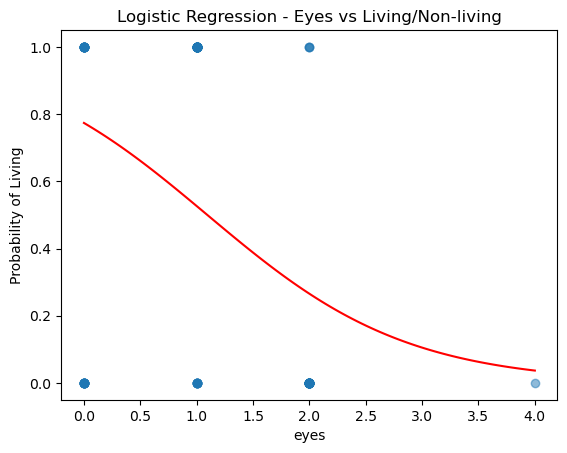

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, ttest_ind 
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

def main():
    src = "C:\\Users\\ammar\\Desktop\\A1_Ammar_Jileidan_40450780\\40450780_features.csv"
    df = pd.read_csv(src)

    # Task 4.1

    y = df["aspect_ratio"]
    x = df[["height","width"]]
    #add intrecpt col
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    #TASK 4.2

    print(model.summary())
    
    #Task 4.3
    livingThings = ["cherry", "banana", "lemon", "tree"]
    df["type"] = np.where(df["label"].isin(livingThings), "living", "nonliving")

    x = df["eyes"]
    y = np.where(df["label"].isin(livingThings), 1, 0)

    X = sm.add_constant(x)
    logit_model = sm.Logit(y, X).fit()
    print(logit_model.summary())

    x_range = np.linspace(df["eyes"].min(), df["eyes"].max(), 100)
    X_range = sm.add_constant(x_range)
    y_pred = logit_model.predict(X_range)

    plt.scatter(x, y, alpha=0.5)
    plt.plot(x_range, y_pred, color='red')
    plt.xlabel("eyes")
    plt.ylabel("Probability of Living")
    plt.title("Logistic Regression - Eyes vs Living/Non-living")
    plt.show()
        






main()